# DhakaNest Rent Prediction — Random Forest

This notebook trains, tunes, validates, analyzes, and exports the Random
Forest rent-prediction candidate using the frozen DhakaNest dataset splits.

The official test dataset is not used for model selection in this notebook.

In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
%pip install -q pandas numpy scikit-learn matplotlib joblib scipy

In [3]:
from pathlib import Path
from datetime import datetime, timezone
from time import perf_counter

import hashlib
import json
import os
import platform
import random
import shutil
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

from sklearn.base import clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    median_absolute_error,
    r2_score,
)
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings("ignore")

print("Python:", platform.python_version())
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Joblib:", joblib.__version__)

Python: 3.12.13
Pandas: 2.2.2
NumPy: 2.0.2
Scikit-learn: 1.6.1
Joblib: 1.5.3


In [4]:
RANDOM_STATE = 42

os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Random state:", RANDOM_STATE)

Random state: 42


In [5]:
PROJECT_ROOT = Path("/content/drive/MyDrive/DhakaNest_ML")

DATA_DIR = PROJECT_ROOT / "data"
SPLITS_DIR = DATA_DIR / "splits"

REPORTS_DIR = PROJECT_ROOT / "reports"
METRICS_DIR = REPORTS_DIR / "metrics"
SEGMENT_DIR = REPORTS_DIR / "segment_evaluation"
RF_FIGURES_DIR = REPORTS_DIR / "figures" / "random_forest"

ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
RF_ARTIFACT_DIR = ARTIFACTS_DIR / "candidates" / "random_forest"

MANIFESTS_DIR = PROJECT_ROOT / "manifests"
LOGS_DIR = PROJECT_ROOT / "logs"

TRAIN_PATH = SPLITS_DIR / "train.csv"
VALIDATION_PATH = SPLITS_DIR / "validation.csv"
TEST_PATH = SPLITS_DIR / "test.csv"

UNSEEN_TRAIN_PATH = SPLITS_DIR / "unseen_micro_area_train.csv"
UNSEEN_CHALLENGE_PATH = (
    SPLITS_DIR / "unseen_micro_area_challenge.csv"
)

for directory in [
    METRICS_DIR,
    SEGMENT_DIR,
    RF_FIGURES_DIR,
    RF_ARTIFACT_DIR,
    MANIFESTS_DIR,
    LOGS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Random Forest artifact directory:", RF_ARTIFACT_DIR)

Project root: /content/drive/MyDrive/DhakaNest_ML
Random Forest artifact directory: /content/drive/MyDrive/DhakaNest_ML/artifacts/candidates/random_forest


In [6]:
required_files = [
    TRAIN_PATH,
    VALIDATION_PATH,
    TEST_PATH,
    UNSEEN_TRAIN_PATH,
    UNSEEN_CHALLENGE_PATH,
]

missing_files = [
    str(path)
    for path in required_files
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "Missing required files:\n"
        + "\n".join(missing_files)
    )

print("All required dataset files exist.")
print("The official test file exists but will not be loaded.")

All required dataset files exist.
The official test file exists but will not be loaded.


In [7]:
LOCAL_WORK_DIR = Path("/content/dhakanest_random_forest")
LOCAL_DATA_DIR = LOCAL_WORK_DIR / "data"

LOCAL_DATA_DIR.mkdir(parents=True, exist_ok=True)

local_train_path = LOCAL_DATA_DIR / "train.csv"
local_validation_path = LOCAL_DATA_DIR / "validation.csv"
local_unseen_train_path = (
    LOCAL_DATA_DIR / "unseen_micro_area_train.csv"
)
local_unseen_challenge_path = (
    LOCAL_DATA_DIR / "unseen_micro_area_challenge.csv"
)

shutil.copy2(TRAIN_PATH, local_train_path)
shutil.copy2(VALIDATION_PATH, local_validation_path)
shutil.copy2(UNSEEN_TRAIN_PATH, local_unseen_train_path)
shutil.copy2(
    UNSEEN_CHALLENGE_PATH,
    local_unseen_challenge_path,
)

print("Working files copied to:", LOCAL_DATA_DIR)

Working files copied to: /content/dhakanest_random_forest/data


In [8]:
train_df = pd.read_csv(local_train_path)
validation_df = pd.read_csv(local_validation_path)

unseen_train_df = pd.read_csv(local_unseen_train_path)
unseen_challenge_df = pd.read_csv(
    local_unseen_challenge_path
)

print("Training shape:", train_df.shape)
print("Validation shape:", validation_df.shape)
print("Unseen training shape:", unseen_train_df.shape)
print("Unseen challenge shape:", unseen_challenge_df.shape)

Training shape: (10668, 11)
Validation shape: (2289, 11)
Unseen training shape: (9549, 11)
Unseen challenge shape: (1119, 11)


In [9]:
CATEGORICAL_FEATURES = [
    "broad_area",
    "model_micro_area",
]

NUMERICAL_FEATURES = [
    "area_sqft",
    "bedrooms",
    "bathrooms",
]

FEATURE_COLUMNS = (
    CATEGORICAL_FEATURES
    + NUMERICAL_FEATURES
)

TARGET_COLUMN = "base_rent_bdt"
GROUP_COLUMN = "duplicate_group_id"

print("Features:", FEATURE_COLUMNS)
print("Target:", TARGET_COLUMN)

Features: ['broad_area', 'model_micro_area', 'area_sqft', 'bedrooms', 'bathrooms']
Target: base_rent_bdt


In [10]:
REQUIRED_COLUMNS = [
    *FEATURE_COLUMNS,
    TARGET_COLUMN,
    GROUP_COLUMN,
    "record_id",
    "micro_area",
    "micro_area_support_count",
]

for dataset_name, dataframe in [
    ("train", train_df),
    ("validation", validation_df),
    ("unseen_train", unseen_train_df),
    ("unseen_challenge", unseen_challenge_df),
]:
    missing_columns = [
        column
        for column in REQUIRED_COLUMNS
        if column not in dataframe.columns
    ]

    if missing_columns:
        raise ValueError(
            f"{dataset_name} is missing columns: "
            f"{missing_columns}"
        )

    if dataframe[FEATURE_COLUMNS + [TARGET_COLUMN]].isna().any().any():
        raise ValueError(
            f"{dataset_name} contains missing model values."
        )

    if (dataframe[TARGET_COLUMN] <= 0).any():
        raise ValueError(
            f"{dataset_name} contains non-positive rent."
        )

print("Dataset schema and value validation passed.")

Dataset schema and value validation passed.


In [11]:
train_record_ids = set(train_df["record_id"])
validation_record_ids = set(validation_df["record_id"])

train_groups = set(train_df[GROUP_COLUMN])
validation_groups = set(validation_df[GROUP_COLUMN])

assert train_record_ids.isdisjoint(validation_record_ids), (
    "Record leakage between training and validation."
)

assert train_groups.isdisjoint(validation_groups), (
    "Duplicate-group leakage between training and validation."
)

print("Training and validation isolation passed.")

Training and validation isolation passed.


In [12]:
X_train = train_df[FEATURE_COLUMNS].copy()
y_train = train_df[TARGET_COLUMN].copy()

X_validation = validation_df[FEATURE_COLUMNS].copy()
y_validation = validation_df[TARGET_COLUMN].copy()

training_groups = train_df[GROUP_COLUMN].copy()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_validation:", X_validation.shape)
print("y_validation:", y_validation.shape)
print("Training groups:", training_groups.nunique())

X_train: (10668, 5)
y_train: (10668,)
X_validation: (2289, 5)
y_validation: (2289,)
Training groups: 9723


In [13]:
environment_info = {
    "python_version": platform.python_version(),
    "pandas_version": pd.__version__,
    "numpy_version": np.__version__,
    "scikit_learn_version": sklearn.__version__,
    "joblib_version": joblib.__version__,
    "random_state": RANDOM_STATE,
    "created_at_utc": datetime.now(
        timezone.utc
    ).isoformat(),
}

ENVIRONMENT_PATH = (
    RF_ARTIFACT_DIR / "training_environment.json"
)

with ENVIRONMENT_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(environment_info, file, indent=2)

print(json.dumps(environment_info, indent=2))
print("Saved:", ENVIRONMENT_PATH)

{
  "python_version": "3.12.13",
  "pandas_version": "2.2.2",
  "numpy_version": "2.0.2",
  "scikit_learn_version": "1.6.1",
  "joblib_version": "1.5.3",
  "random_state": 42,
  "created_at_utc": "2026-07-31T04:05:39.026501+00:00"
}
Saved: /content/drive/MyDrive/DhakaNest_ML/artifacts/candidates/random_forest/training_environment.json


## Preprocessing

Categorical features are one-hot encoded, while numerical features receive
median imputation if necessary. Unknown future categories are ignored safely.

In [14]:
def create_preprocessor(
    categorical_features=None,
    numerical_features=None,
):
    categorical_features = (
        categorical_features
        if categorical_features is not None
        else CATEGORICAL_FEATURES
    )

    numerical_features = (
        numerical_features
        if numerical_features is not None
        else NUMERICAL_FEATURES
    )

    transformers = []

    if categorical_features:
        categorical_pipeline = Pipeline(
            steps=[
                (
                    "imputer",
                    SimpleImputer(
                        strategy="most_frequent"
                    ),
                ),
                (
                    "onehot",
                    OneHotEncoder(
                        handle_unknown="ignore",
                        sparse_output=True,
                    ),
                ),
            ]
        )

        transformers.append(
            (
                "categorical",
                categorical_pipeline,
                categorical_features,
            )
        )

    if numerical_features:
        numerical_pipeline = Pipeline(
            steps=[
                (
                    "imputer",
                    SimpleImputer(
                        strategy="median"
                    ),
                ),
            ]
        )

        transformers.append(
            (
                "numerical",
                numerical_pipeline,
                numerical_features,
            )
        )

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        sparse_threshold=1.0,
    )


preprocessor = create_preprocessor()

print(preprocessor)

ColumnTransformer(sparse_threshold=1.0,
                  transformers=[('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['broad_area', 'model_micro_area']),
                                ('numerical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['area_sqft', 'bedrooms', 'bathrooms'])])


In [15]:
def calculate_regression_metrics(
    y_true,
    y_pred,
):
    y_true_array = np.asarray(y_true, dtype=float)
    y_pred_array = np.asarray(y_pred, dtype=float)

    absolute_errors = np.abs(
        y_true_array - y_pred_array
    )

    return {
        "mae_bdt": float(
            mean_absolute_error(
                y_true_array,
                y_pred_array,
            )
        ),
        "rmse_bdt": float(
            np.sqrt(
                mean_squared_error(
                    y_true_array,
                    y_pred_array,
                )
            )
        ),
        "r2": float(
            r2_score(
                y_true_array,
                y_pred_array,
            )
        ),
        "mape_percent": float(
            mean_absolute_percentage_error(
                y_true_array,
                y_pred_array,
            )
            * 100
        ),
        "median_absolute_error_bdt": float(
            median_absolute_error(
                y_true_array,
                y_pred_array,
            )
        ),
        "p90_absolute_error_bdt": float(
            np.percentile(
                absolute_errors,
                90,
            )
        ),
    }


def evaluate_fitted_model(
    model,
    X,
    y,
):
    prediction_start = perf_counter()

    predictions = model.predict(X)

    prediction_seconds = (
        perf_counter() - prediction_start
    )

    metrics = calculate_regression_metrics(
        y,
        predictions,
    )

    metrics["prediction_time_seconds"] = float(
        prediction_seconds
    )

    metrics["milliseconds_per_record"] = float(
        prediction_seconds
        / max(len(X), 1)
        * 1000
    )

    return metrics, predictions

In [16]:
def flatten_model_result(
    model_name,
    train_metrics,
    validation_metrics,
    training_time_seconds,
):
    return {
        "model_name": model_name,
        "training_time_seconds": float(
            training_time_seconds
        ),
        "train_mae_bdt": train_metrics["mae_bdt"],
        "validation_mae_bdt": (
            validation_metrics["mae_bdt"]
        ),
        "validation_rmse_bdt": (
            validation_metrics["rmse_bdt"]
        ),
        "validation_r2": validation_metrics["r2"],
        "validation_mape_percent": (
            validation_metrics["mape_percent"]
        ),
        "validation_median_absolute_error_bdt": (
            validation_metrics[
                "median_absolute_error_bdt"
            ]
        ),
        "validation_p90_absolute_error_bdt": (
            validation_metrics[
                "p90_absolute_error_bdt"
            ]
        ),
        "train_validation_mae_gap_bdt": float(
            validation_metrics["mae_bdt"]
            - train_metrics["mae_bdt"]
        ),
        "validation_prediction_time_seconds": (
            validation_metrics[
                "prediction_time_seconds"
            ]
        ),
    }

## Dummy Baseline

The baseline predicts the training-set median rent for every property. The
Random Forest candidate must clearly outperform this baseline.

In [17]:
dummy_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            create_preprocessor(),
        ),
        (
            "model",
            DummyRegressor(
                strategy="median"
            ),
        ),
    ]
)

dummy_start = perf_counter()

dummy_pipeline.fit(
    X_train,
    y_train,
)

dummy_training_time = (
    perf_counter() - dummy_start
)

dummy_train_metrics, _ = evaluate_fitted_model(
    dummy_pipeline,
    X_train,
    y_train,
)

dummy_validation_metrics, dummy_validation_predictions = (
    evaluate_fitted_model(
        dummy_pipeline,
        X_validation,
        y_validation,
    )
)

print("Dummy training metrics:")
display(pd.DataFrame([dummy_train_metrics]))

print("Dummy validation metrics:")
display(pd.DataFrame([dummy_validation_metrics]))

Dummy training metrics:


,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt,prediction_time_seconds,milliseconds_per_record
0,9785.46213,25280.329656,-0.062665,32.313069,5000.0,18000.0,0.028361,0.002658


Dummy validation metrics:


,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt,prediction_time_seconds,milliseconds_per_record
0,9648.186981,23000.801441,-0.072099,32.733671,5000.0,18200.0,0.016135,0.007049


## Initial Random Forest

An initial model is trained before hyperparameter tuning to establish a
reasonable Random Forest reference result.

In [18]:
initial_rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            create_preprocessor(),
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                bootstrap=True,
                oob_score=True,
            ),
        ),
    ]
)

initial_start = perf_counter()

initial_rf_pipeline.fit(
    X_train,
    y_train,
)

initial_training_time = (
    perf_counter() - initial_start
)

initial_train_metrics, _ = evaluate_fitted_model(
    initial_rf_pipeline,
    X_train,
    y_train,
)

initial_validation_metrics, initial_validation_predictions = (
    evaluate_fitted_model(
        initial_rf_pipeline,
        X_validation,
        y_validation,
    )
)

initial_rf_estimator = (
    initial_rf_pipeline.named_steps["model"]
)

print("Initial Random Forest OOB R²:")
print(initial_rf_estimator.oob_score_)

print("\nInitial training metrics:")
display(pd.DataFrame([initial_train_metrics]))

print("\nInitial validation metrics:")
display(pd.DataFrame([initial_validation_metrics]))

Initial Random Forest OOB R²:
0.8185995228071281

Initial training metrics:


,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt,prediction_time_seconds,milliseconds_per_record
0,2093.050639,5345.624808,0.952485,8.425925,1106.516384,4049.571296,0.641795,0.060161



Initial validation metrics:


,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt,prediction_time_seconds,milliseconds_per_record
0,4017.41422,9738.415808,0.807812,14.535534,1921.24373,7401.454819,0.219672,0.095968


## Random Forest Hyperparameter Tuning

Randomized search uses five-fold group cross-validation. Model selection is
based on cross-validated MAE from the training dataset only.

In [19]:
tuning_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            create_preprocessor(),
        ),
        (
            "model",
            RandomForestRegressor(
                random_state=RANDOM_STATE,
                n_jobs=1,
                bootstrap=True,
            ),
        ),
    ]
)

In [20]:
parameter_distributions = {
    "model__n_estimators": [
        300,
        500,
        700,
    ],
    "model__max_depth": [
        None,
        15,
        25,
        35,
    ],
    "model__min_samples_split": [
        2,
        5,
        10,
    ],
    "model__min_samples_leaf": [
        1,
        2,
        4,
    ],
    "model__max_features": [
        "sqrt",
        0.50,
        0.75,
        1.0,
    ],
    "model__max_samples": [
        None,
        0.70,
        0.85,
    ],
}

print("Hyperparameter search space configured.")

Hyperparameter search space configured.


In [21]:
group_cv = GroupKFold(
    n_splits=5
)

search = RandomizedSearchCV(
    estimator=tuning_pipeline,
    param_distributions=parameter_distributions,
    n_iter=15,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    cv=group_cv,
    verbose=2,
    random_state=RANDOM_STATE,
    refit=True,
    return_train_score=True,
    error_score="raise",
)

print("Randomized search configured.")
print("Candidates:", search.n_iter)
print("Cross-validation folds:", 5)
print("Total fits:", search.n_iter * 5)

Randomized search configured.
Candidates: 15
Cross-validation folds: 5
Total fits: 75


In [22]:
tuning_start = perf_counter()

search.fit(
    X_train,
    y_train,
    groups=training_groups,
)

tuning_time_seconds = (
    perf_counter() - tuning_start
)

print("Tuning completed.")
print("Tuning time in seconds:", tuning_time_seconds)
print("Best cross-validation MAE:", -search.best_score_)
print("Best parameters:")

display(
    pd.DataFrame(
        list(search.best_params_.items()),
        columns=["parameter", "value"],
    )
)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Tuning completed.
Tuning time in seconds: 1271.1542791169998
Best cross-validation MAE: 3702.7824934176338
Best parameters:


,parameter,value
0,model__n_estimators,500.0
1,model__min_samples_split,10.0
2,model__min_samples_leaf,1.0
3,model__max_samples,NaN
4,model__max_features,0.5
5,model__max_depth,25.0


In [23]:
cv_results_df = pd.DataFrame(
    search.cv_results_
)

cv_results_df["mean_test_mae_bdt"] = (
    -cv_results_df["mean_test_score"]
)

cv_results_df["mean_train_mae_bdt"] = (
    -cv_results_df["mean_train_score"]
)

cv_results_df = cv_results_df.sort_values(
    "mean_test_mae_bdt",
    ascending=True,
)

CV_RESULTS_PATH = (
    METRICS_DIR
    / "random_forest_cv_results.csv"
)

cv_results_df.to_csv(
    CV_RESULTS_PATH,
    index=False,
)

display(
    cv_results_df[
        [
            "rank_test_score",
            "mean_test_mae_bdt",
            "std_test_score",
            "mean_train_mae_bdt",
            "mean_fit_time",
            "params",
        ]
    ].head(15)
)

print("Saved:", CV_RESULTS_PATH)

,rank_test_score,mean_test_mae_bdt,std_test_score,mean_train_mae_bdt,mean_fit_time,params
10,1,3702.782493,165.412464,2930.160442,41.508092,"{'model__n_estimators': 500, 'model__min_sampl..."
3,2,3722.492924,127.501234,2930.702830,13.934687,"{'model__n_estimators': 300, 'model__min_sampl..."
2,3,3732.365456,146.433428,3078.781167,40.629104,"{'model__n_estimators': 500, 'model__min_sampl..."
5,4,3754.889856,100.836476,3260.253340,28.903384,"{'model__n_estimators': 700, 'model__min_sampl..."
11,5,3824.878892,141.528181,3345.233077,24.383290,"{'model__n_estimators': 300, 'model__min_sampl..."
4,6,3855.154219,130.489977,3273.460836,37.150495,"{'model__n_estimators': 300, 'model__min_sampl..."
9,7,3871.634943,135.359984,3607.682088,14.597608,"{'model__n_estimators': 500, 'model__min_sampl..."
8,8,3872.298432,136.382496,3355.445076,68.631471,"{'model__n_estimators': 700, 'model__min_sampl..."
14,9,3902.000261,136.421218,3330.367142,60.801731,"{'model__n_estimators': 500, 'model__min_sampl..."
7,10,3913.062990,154.409850,3350.724843,40.656308,"{'model__n_estimators': 500, 'model__min_sampl..."


Saved: /content/drive/MyDrive/DhakaNest_ML/reports/metrics/random_forest_cv_results.csv


In [24]:
best_raw_pipeline = search.best_estimator_

# Allow the final fitted forest to use all CPU cores for prediction.
best_raw_pipeline.named_steps["model"].set_params(
    n_jobs=-1
)

raw_train_metrics, raw_train_predictions = (
    evaluate_fitted_model(
        best_raw_pipeline,
        X_train,
        y_train,
    )
)

raw_validation_metrics, raw_validation_predictions = (
    evaluate_fitted_model(
        best_raw_pipeline,
        X_validation,
        y_validation,
    )
)

print("Tuned raw-target training metrics:")
display(pd.DataFrame([raw_train_metrics]))

print("Tuned raw-target validation metrics:")
display(pd.DataFrame([raw_validation_metrics]))

Tuned raw-target training metrics:


,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt,prediction_time_seconds,milliseconds_per_record
0,2965.137366,7226.978172,0.913155,11.684827,1654.297366,5775.655809,2.247363,0.210664


Tuned raw-target validation metrics:


,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt,prediction_time_seconds,milliseconds_per_record
0,3792.080605,8894.933733,0.839663,14.083764,1823.854926,7173.042082,0.847039,0.370047


## Raw-Rent Versus Log-Rent Target

The tuned Random Forest settings are also evaluated using `log1p` rent as the
training target. Predictions are automatically converted back to BDT before
evaluation.

In [25]:
log_target_regressor = TransformedTargetRegressor(
    regressor=clone(best_raw_pipeline),
    func=np.log1p,
    inverse_func=np.expm1,
    check_inverse=True,
)

log_training_start = perf_counter()

log_target_regressor.fit(
    X_train,
    y_train,
)

log_training_time = (
    perf_counter() - log_training_start
)

log_train_metrics, log_train_predictions = (
    evaluate_fitted_model(
        log_target_regressor,
        X_train,
        y_train,
    )
)

log_validation_metrics, log_validation_predictions = (
    evaluate_fitted_model(
        log_target_regressor,
        X_validation,
        y_validation,
    )
)

print("Log-target training metrics:")
display(pd.DataFrame([log_train_metrics]))

print("Log-target validation metrics:")
display(pd.DataFrame([log_validation_metrics]))

Log-target training metrics:


,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt,prediction_time_seconds,milliseconds_per_record
0,2919.409831,7959.790203,0.89465,11.016586,1561.961032,5501.574908,0.619511,0.058072


Log-target validation metrics:


,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt,prediction_time_seconds,milliseconds_per_record
0,3721.740995,9009.874607,0.835492,13.600309,1792.660325,6854.28643,0.236707,0.103411


In [26]:
comparison_rows = [
    flatten_model_result(
        "Dummy Median Baseline",
        dummy_train_metrics,
        dummy_validation_metrics,
        dummy_training_time,
    ),
    flatten_model_result(
        "Initial Random Forest",
        initial_train_metrics,
        initial_validation_metrics,
        initial_training_time,
    ),
    flatten_model_result(
        "Tuned Random Forest — Raw Target",
        raw_train_metrics,
        raw_validation_metrics,
        tuning_time_seconds,
    ),
    flatten_model_result(
        "Tuned Random Forest — Log Target",
        log_train_metrics,
        log_validation_metrics,
        log_training_time,
    ),
]

rf_comparison_df = pd.DataFrame(
    comparison_rows
).sort_values(
    "validation_mae_bdt",
    ascending=True,
)

RF_COMPARISON_PATH = (
    METRICS_DIR
    / "random_forest_validation_comparison.csv"
)

rf_comparison_df.to_csv(
    RF_COMPARISON_PATH,
    index=False,
)

display(rf_comparison_df)

print("Saved:", RF_COMPARISON_PATH)

,model_name,training_time_seconds,train_mae_bdt,validation_mae_bdt,validation_rmse_bdt,validation_r2,validation_mape_percent,validation_median_absolute_error_bdt,validation_p90_absolute_error_bdt,train_validation_mae_gap_bdt,validation_prediction_time_seconds
3,Tuned Random Forest — Log Target,32.087574,2919.409831,3721.740995,9009.874607,0.835492,13.600309,1792.660325,6854.286430,802.331164,0.236707
2,Tuned Random Forest — Raw Target,1271.154279,2965.137366,3792.080605,8894.933733,0.839663,14.083764,1823.854926,7173.042082,826.943239,0.847039
1,Initial Random Forest,73.837459,2093.050639,4017.414220,9738.415808,0.807812,14.535534,1921.243730,7401.454819,1924.363582,0.219672
0,Dummy Median Baseline,0.103193,9785.462130,9648.186981,23000.801441,-0.072099,32.733671,5000.000000,18200.000000,-137.275149,0.016135


Saved: /content/drive/MyDrive/DhakaNest_ML/reports/metrics/random_forest_validation_comparison.csv


In [27]:
if (
    log_validation_metrics["mae_bdt"]
    < raw_validation_metrics["mae_bdt"]
):
    chosen_model = log_target_regressor
    chosen_target_strategy = "log1p"
    chosen_train_metrics = log_train_metrics
    chosen_validation_metrics = (
        log_validation_metrics
    )
    chosen_train_predictions = (
        log_train_predictions
    )
    chosen_validation_predictions = (
        log_validation_predictions
    )
else:
    chosen_model = best_raw_pipeline
    chosen_target_strategy = "raw"
    chosen_train_metrics = raw_train_metrics
    chosen_validation_metrics = (
        raw_validation_metrics
    )
    chosen_train_predictions = (
        raw_train_predictions
    )
    chosen_validation_predictions = (
        raw_validation_predictions
    )

print("Selected target strategy:", chosen_target_strategy)
print(
    "Selected validation MAE:",
    chosen_validation_metrics["mae_bdt"],
)

Selected target strategy: log1p
Selected validation MAE: 3721.740994715749


In [28]:
validation_results_df = validation_df[
    [
        "record_id",
        "location_raw",
        "broad_area",
        "micro_area",
        "model_micro_area",
        "micro_area_support_count",
        "area_sqft",
        "bedrooms",
        "bathrooms",
        "base_rent_bdt",
    ]
].copy()

validation_results_df["predicted_rent_bdt"] = (
    np.maximum(
        chosen_validation_predictions,
        0,
    )
)

validation_results_df["residual_bdt"] = (
    validation_results_df["base_rent_bdt"]
    - validation_results_df["predicted_rent_bdt"]
)

validation_results_df["absolute_error_bdt"] = (
    validation_results_df[
        "residual_bdt"
    ].abs()
)

validation_results_df["absolute_percentage_error"] = (
    validation_results_df["absolute_error_bdt"]
    / validation_results_df["base_rent_bdt"]
    * 100
)

VALIDATION_PREDICTIONS_PATH = (
    METRICS_DIR
    / "random_forest_validation_predictions.csv"
)

validation_results_df.to_csv(
    VALIDATION_PREDICTIONS_PATH,
    index=False,
)

display(validation_results_df.head(20))

print("Saved:", VALIDATION_PREDICTIONS_PATH)

,record_id,location_raw,broad_area,micro_area,model_micro_area,micro_area_support_count,area_sqft,bedrooms,bathrooms,base_rent_bdt,predicted_rent_bdt,residual_bdt,absolute_error_bdt,absolute_percentage_error
0,DN-000004,"Gulshan 1, Gulshan, Dhaka",Gulshan,Gulshan 1,Gulshan 1,82,2200,3,4,75000,70921.033431,4078.966569,4078.966569,5.438622
1,DN-000006,"Bashundhara R-A, Dhaka",Bashundhara R/A,Bashundhara R/A,OTHER_BASHUNDHARA_R_A,17,3000,4,5,50000,70496.953905,-20496.953905,20496.953905,40.993908
2,DN-000018,"Block K, Baridhara, Dhaka",Baridhara,Block K,Block K,34,3000,4,4,160000,178044.944263,-18044.944263,18044.944263,11.278090
3,DN-000030,"Rajabazar, Tejgaon, Dhaka",Tejgaon,Rajabazar,Rajabazar,43,650,2,2,18000,17757.041335,242.958665,242.958665,1.349770
4,DN-000038,"Block G, Bashundhara R-A, Dhaka",Bashundhara R/A,Block G,Block G,121,1750,3,4,30000,28462.974687,1537.025313,1537.025313,5.123418
5,DN-000050,"Block A, Bashundhara R-A, Dhaka",Bashundhara R/A,Block A,Block A,79,1860,3,4,38000,37545.006678,454.993322,454.993322,1.197351
6,DN-000055,"Block G, Bashundhara R-A, Dhaka",Bashundhara R/A,Block G,Block G,121,1400,3,3,28000,27006.251569,993.748431,993.748431,3.549102
7,DN-000058,"Malibagh, Dhaka",Malibagh,Malibagh,Malibagh,109,1300,3,3,30000,26434.803242,3565.196758,3565.196758,11.883989
8,DN-000060,"West Dhanmondi and Shangkar, Dhanmondi, Dhaka",Dhanmondi,West Dhanmondi And Shangkar,West Dhanmondi And Shangkar,94,1000,3,2,18000,19725.863310,-1725.863310,1725.863310,9.588130
9,DN-000062,"Block F, Bashundhara R-A, Dhaka",Bashundhara R/A,Block F,Block F,99,1800,3,4,30000,32705.304134,-2705.304134,2705.304134,9.017680


Saved: /content/drive/MyDrive/DhakaNest_ML/reports/metrics/random_forest_validation_predictions.csv


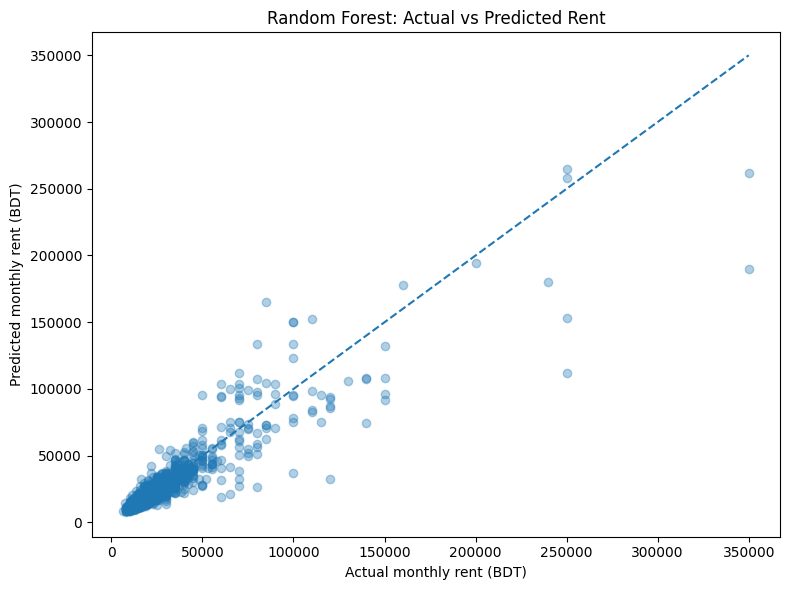

Saved: /content/drive/MyDrive/DhakaNest_ML/reports/figures/random_forest/actual_vs_predicted.png


In [29]:
plt.figure(figsize=(8, 6))

plt.scatter(
    validation_results_df["base_rent_bdt"],
    validation_results_df["predicted_rent_bdt"],
    alpha=0.35,
)

minimum_value = min(
    validation_results_df["base_rent_bdt"].min(),
    validation_results_df["predicted_rent_bdt"].min(),
)

maximum_value = max(
    validation_results_df["base_rent_bdt"].max(),
    validation_results_df["predicted_rent_bdt"].max(),
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
)

plt.xlabel("Actual monthly rent (BDT)")
plt.ylabel("Predicted monthly rent (BDT)")
plt.title("Random Forest: Actual vs Predicted Rent")
plt.tight_layout()

ACTUAL_PREDICTED_FIGURE_PATH = (
    RF_FIGURES_DIR
    / "actual_vs_predicted.png"
)

plt.savefig(
    ACTUAL_PREDICTED_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Saved:", ACTUAL_PREDICTED_FIGURE_PATH)

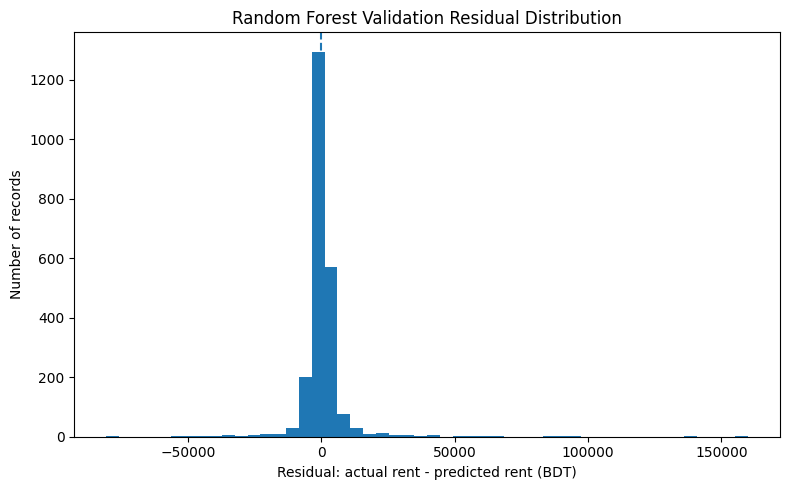

Saved: /content/drive/MyDrive/DhakaNest_ML/reports/figures/random_forest/validation_residual_distribution.png


In [30]:
plt.figure(figsize=(8, 5))

plt.hist(
    validation_results_df["residual_bdt"],
    bins=50,
)

plt.axvline(
    0,
    linestyle="--",
)

plt.xlabel("Residual: actual rent - predicted rent (BDT)")
plt.ylabel("Number of records")
plt.title("Random Forest Validation Residual Distribution")
plt.tight_layout()

RESIDUAL_FIGURE_PATH = (
    RF_FIGURES_DIR
    / "validation_residual_distribution.png"
)

plt.savefig(
    RESIDUAL_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Saved:", RESIDUAL_FIGURE_PATH)

In [31]:
largest_errors_df = (
    validation_results_df.sort_values(
        "absolute_error_bdt",
        ascending=False,
    )
    .head(30)
)

display(
    largest_errors_df[
        [
            "record_id",
            "location_raw",
            "area_sqft",
            "bedrooms",
            "bathrooms",
            "base_rent_bdt",
            "predicted_rent_bdt",
            "absolute_error_bdt",
            "absolute_percentage_error",
        ]
    ]
)

LARGEST_ERRORS_PATH = (
    METRICS_DIR
    / "random_forest_largest_validation_errors.csv"
)

largest_errors_df.to_csv(
    LARGEST_ERRORS_PATH,
    index=False,
)

print("Saved:", LARGEST_ERRORS_PATH)

,record_id,location_raw,area_sqft,bedrooms,bathrooms,base_rent_bdt,predicted_rent_bdt,absolute_error_bdt,absolute_percentage_error
222,DN-001737,"Baridhara, Dhaka",3850,3,3,350000,190062.505430,159937.494570,45.696427
23,DN-000182,"Gulshan 2, Gulshan, Dhaka",2800,4,4,250000,111787.879116,138212.120884,55.284848
1634,DN-018936,"Gulshan 2, Gulshan, Dhaka",3200,4,4,250000,153062.845445,96937.154555,38.774862
1446,DN-016537,"Baridhara, Dhaka",4550,4,4,350000,261438.169078,88561.830922,25.303380
50,DN-000388,"Block A, Bashundhara R-A, Dhaka",1450,3,3,120000,32257.311015,87742.688985,73.118907
1421,DN-016172,"Gulshan 2, Gulshan, Dhaka",3267,4,4,85000,165516.526279,80516.526279,94.725325
1423,DN-016217,"Baridhara DOHS, Dhaka",2800,4,4,140000,74617.142500,65382.857500,46.702041
2050,DN-024851,"Avenue 6, Mirpur DOHS, Mirpur, Dhaka",2200,3,3,100000,37156.096898,62843.903102,62.843903
16,DN-000113,"Block K, Baridhara, Dhaka",3000,3,4,240000,179890.115478,60109.884522,25.045785
129,DN-001042,"Gulshan 2, Gulshan, Dhaka",2350,3,3,150000,92022.591861,57977.408139,38.651605


Saved: /content/drive/MyDrive/DhakaNest_ML/reports/metrics/random_forest_largest_validation_errors.csv


In [32]:
validation_results_df["micro_area_support_level"] = pd.cut(
    validation_results_df["micro_area_support_count"],
    bins=[
        -np.inf,
        29,
        99,
        np.inf,
    ],
    labels=[
        "low",
        "normal",
        "high",
    ],
)

validation_results_df["rent_range"] = pd.cut(
    validation_results_df["base_rent_bdt"],
    bins=[
        -np.inf,
        15_000,
        30_000,
        60_000,
        np.inf,
    ],
    labels=[
        "below_15000",
        "15000_to_30000",
        "30001_to_60000",
        "above_60000",
    ],
)

validation_results_df["area_range"] = pd.cut(
    validation_results_df["area_sqft"],
    bins=[
        -np.inf,
        700,
        1000,
        1500,
        2500,
        np.inf,
    ],
    labels=[
        "up_to_700",
        "701_to_1000",
        "1001_to_1500",
        "1501_to_2500",
        "above_2500",
    ],
)

print("Evaluation segments created.")

Evaluation segments created.


In [33]:
def calculate_segment_metrics(
    dataframe,
    segment_column,
):
    rows = []

    for segment_value, group in dataframe.groupby(
        segment_column,
        dropna=False,
        observed=False,
    ):
        if len(group) == 0:
            continue

        metrics = calculate_regression_metrics(
            group["base_rent_bdt"],
            group["predicted_rent_bdt"],
        )

        rows.append({
            "segment": str(segment_value),
            "record_count": int(len(group)),
            **metrics,
        })

    return (
        pd.DataFrame(rows)
        .sort_values(
            "mae_bdt",
            ascending=False,
        )
        .reset_index(drop=True)
    )

In [34]:
segment_definitions = {
    "broad_area": "broad_area",
    "model_micro_area": "model_micro_area",
    "micro_area_support": "micro_area_support_level",
    "bedroom_count": "bedrooms",
    "bathroom_count": "bathrooms",
    "rent_range": "rent_range",
    "area_range": "area_range",
}

segment_result_tables = {}

for output_name, segment_column in segment_definitions.items():
    result_df = calculate_segment_metrics(
        validation_results_df,
        segment_column,
    )

    segment_result_tables[output_name] = result_df

    output_path = (
        SEGMENT_DIR
        / f"random_forest_by_{output_name}.csv"
    )

    result_df.to_csv(
        output_path,
        index=False,
    )

    print("\nSegment:", output_name)
    display(result_df.head(20))
    print("Saved:", output_path)


Segment: broad_area


,segment,record_count,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt
0,Baridhara,13,42050.790885,59236.484954,0.691039,26.470218,35288.718255,82871.441642
1,Gulshan,34,31453.683683,42192.457332,0.427307,32.130044,23822.941416,56611.517877
2,Mohakhali DOHS,3,29051.441696,36188.216015,0.374667,28.217260,31611.743765,49606.659578
3,Banani DOHS,2,18693.757759,19454.455702,0.394439,17.578565,18693.757759,23003.320522
4,Banani,16,17327.831458,21408.767568,0.056612,21.043030,14532.398418,34260.539876
5,Baridhara DOHS,8,16632.410466,25681.408123,0.327863,22.803098,9885.119143,36126.071456
6,Banglamotors,1,9715.877615,9715.877615,NaN,32.386259,9715.877615,9715.877615
7,Turag,1,7430.733086,7430.733086,NaN,37.153665,7430.733086,7430.733086
8,Demra,1,7228.414649,7228.414649,NaN,96.378862,7228.414649,7228.414649
9,Dhanmondi,70,6469.549895,9597.172148,0.832185,15.289185,3936.519904,14858.518726


Saved: /content/drive/MyDrive/DhakaNest_ML/reports/segment_evaluation/random_forest_by_broad_area.csv

Segment: model_micro_area


,segment,record_count,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt
0,Baridhara,5,63535.255863,84142.878744,0.483059,30.006473,35288.718255,131387.229111
1,Gulshan 2,18,39715.747258,52178.488477,0.318194,32.953667,29622.260046,85442.714762
2,Block K,5,37098.423162,41173.497423,0.618543,32.212772,42159.362604,56234.388502
3,OTHER_MOHAKHALI_DOHS,3,29051.441696,36188.216015,0.374667,28.217260,31611.743765,49606.659578
4,Gulshan 1,16,22158.862161,26833.064513,0.403098,31.203469,21483.832953,44577.861989
5,OTHER_BANANI_DOHS,2,18693.757759,19454.455702,0.394439,17.578565,18693.757759,23003.320522
6,Banani,16,17327.831458,21408.767568,0.056612,21.043030,14532.398418,34260.539876
7,Baridhara DOHS,8,16632.410466,25681.408123,0.327863,22.803098,9885.119143,36126.071456
8,OTHER_BARIDHARA,3,14497.295462,24083.813922,0.801133,11.005534,984.045848,33552.693697
9,Sector 1,8,12683.938439,17364.726784,-0.634329,25.678177,9111.243146,26988.498838


Saved: /content/drive/MyDrive/DhakaNest_ML/reports/segment_evaluation/random_forest_by_model_micro_area.csv

Segment: micro_area_support


...

Saved: /content/drive/MyDrive/DhakaNest_ML/reports/segment_evaluation/random_forest_by_bathroom_count.csv

Segment: rent_range


,segment,record_count,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt
0,above_60000,85,30554.577452,41147.870865,0.506617,28.399978,23587.448866,59256.893969
1,30001_to_60000,234,6929.000103,9945.418219,-0.676176,16.370656,5063.627742,14667.169772
2,15000_to_30000,1059,2760.960986,3776.905342,0.222823,12.812534,2068.937166,5848.066419
3,below_15000,911,1511.177108,2000.728206,-0.174765,12.423603,1171.899420,3181.525353


Saved: /content/drive/MyDrive/DhakaNest_ML/reports/segment_evaluation/random_forest_by_rent_range.csv

Segment: area_range


,segment,record_count,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt
0,above_2500,57,30308.846683,43655.959939,0.602667,24.763567,20962.765864,62219.073713
1,1501_to_2500,298,7726.694787,12038.213421,0.582192,18.556120,4930.076877,19204.232708
2,1001_to_1500,757,3236.255152,5842.023871,0.466689,13.486374,2310.778215,6389.528123
3,701_to_1000,640,1980.100859,3125.230634,0.436116,12.280123,1559.389159,4051.475559
4,up_to_700,537,1437.236740,1886.212840,0.487928,11.399250,1113.086467,3256.828014


Saved: /content/drive/MyDrive/DhakaNest_ML/reports/segment_evaluation/random_forest_by_area_range.csv


In [35]:
if chosen_target_strategy == "log1p":
    fitted_rf_pipeline = chosen_model.regressor_
else:
    fitted_rf_pipeline = chosen_model

fitted_preprocessor = (
    fitted_rf_pipeline.named_steps["preprocessor"]
)

fitted_rf_estimator = (
    fitted_rf_pipeline.named_steps["model"]
)

print("Fitted Random Forest extracted.")

Fitted Random Forest extracted.


In [36]:
feature_names = (
    fitted_preprocessor.get_feature_names_out()
)

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": fitted_rf_estimator.feature_importances_,
}).sort_values(
    "importance",
    ascending=False,
)

FEATURE_IMPORTANCE_PATH = (
    METRICS_DIR
    / "random_forest_feature_importance.csv"
)

feature_importance_df.to_csv(
    FEATURE_IMPORTANCE_PATH,
    index=False,
)

display(feature_importance_df.head(30))

print("Saved:", FEATURE_IMPORTANCE_PATH)

,feature,importance
265,numerical__area_sqft,0.573592
267,numerical__bathrooms,0.146716
266,numerical__bedrooms,0.066455
18,categorical__broad_area_Gulshan,0.034008
9,categorical__broad_area_Baridhara,0.019626
40,categorical__broad_area_Mirpur,0.019061
114,categorical__model_micro_area_Gulshan 2,0.010367
14,categorical__broad_area_Dakshin Khan,0.007206
78,categorical__model_micro_area_Baridhara,0.007189
4,categorical__broad_area_Banani,0.005015


Saved: /content/drive/MyDrive/DhakaNest_ML/reports/metrics/random_forest_feature_importance.csv


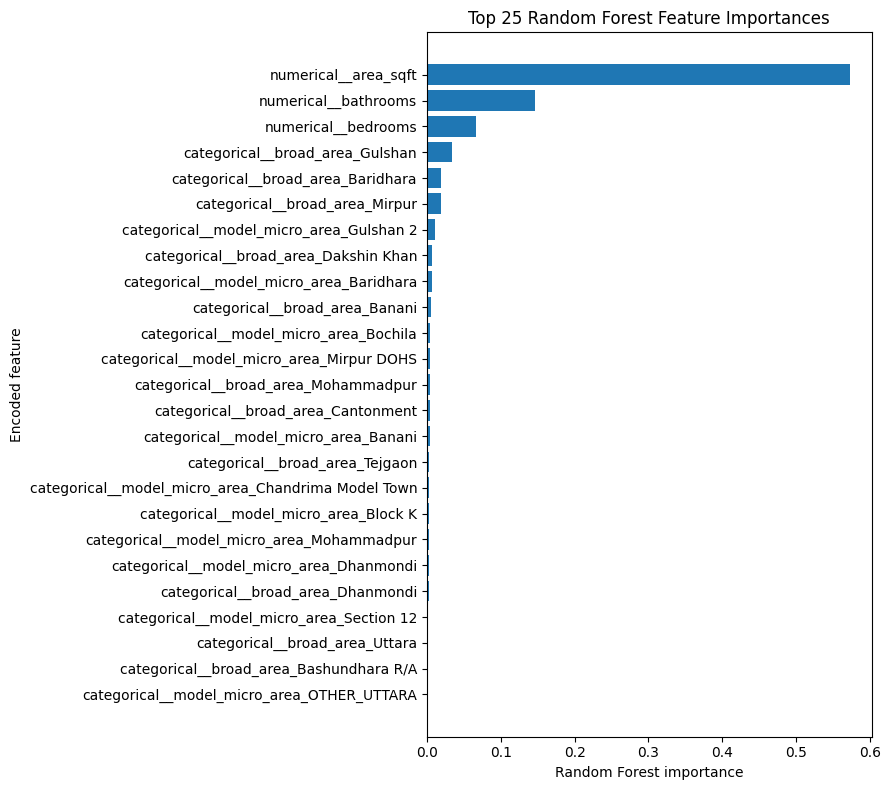

Saved: /content/drive/MyDrive/DhakaNest_ML/reports/figures/random_forest/feature_importance_top_25.png


In [37]:
top_feature_importance_df = (
    feature_importance_df.head(25)
    .sort_values(
        "importance",
        ascending=True,
    )
)

plt.figure(figsize=(9, 8))

plt.barh(
    top_feature_importance_df["feature"],
    top_feature_importance_df["importance"],
)

plt.xlabel("Random Forest importance")
plt.ylabel("Encoded feature")
plt.title("Top 25 Random Forest Feature Importances")
plt.tight_layout()

FEATURE_IMPORTANCE_FIGURE_PATH = (
    RF_FIGURES_DIR
    / "feature_importance_top_25.png"
)

plt.savefig(
    FEATURE_IMPORTANCE_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Saved:", FEATURE_IMPORTANCE_FIGURE_PATH)

## Unseen Micro-Area Challenge

Complete micro-areas are withheld from a special training subset. This checks
how the Random Forest behaves when a submitted micro-area was not represented
during challenge training.

In [38]:
X_unseen_train = unseen_train_df[
    FEATURE_COLUMNS
].copy()

y_unseen_train = unseen_train_df[
    TARGET_COLUMN
].copy()

X_unseen_challenge = unseen_challenge_df[
    FEATURE_COLUMNS
].copy()

y_unseen_challenge = unseen_challenge_df[
    TARGET_COLUMN
].copy()

print("Challenge training rows:", len(X_unseen_train))
print("Challenge evaluation rows:", len(X_unseen_challenge))

Challenge training rows: 9549
Challenge evaluation rows: 1119


In [39]:
unseen_primary_model = clone(chosen_model)

unseen_primary_start = perf_counter()

unseen_primary_model.fit(
    X_unseen_train,
    y_unseen_train,
)

unseen_primary_training_time = (
    perf_counter() - unseen_primary_start
)

unseen_primary_metrics, unseen_primary_predictions = (
    evaluate_fitted_model(
        unseen_primary_model,
        X_unseen_challenge,
        y_unseen_challenge,
    )
)

print("Unseen micro-area primary-pipeline metrics:")
display(pd.DataFrame([unseen_primary_metrics]))

Unseen micro-area primary-pipeline metrics:


,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt,prediction_time_seconds,milliseconds_per_record
0,2843.29996,3994.73119,0.658183,15.610216,2136.471094,6259.810468,0.235567,0.210516


In [40]:
best_rf_parameters = {
    key.replace("model__", ""): value
    for key, value in search.best_params_.items()
}

best_rf_parameters.update({
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "bootstrap": True,
})

display(
    pd.DataFrame(
        list(best_rf_parameters.items()),
        columns=["parameter", "value"],
    )
)

,parameter,value
0,n_estimators,500
1,min_samples_split,10
2,min_samples_leaf,1
3,max_samples,None
4,max_features,0.5
5,max_depth,25
6,random_state,42
7,n_jobs,-1
8,bootstrap,True


In [41]:
BROAD_FALLBACK_FEATURES = [
    "broad_area",
    "area_sqft",
    "bedrooms",
    "bathrooms",
]

broad_fallback_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            create_preprocessor(
                categorical_features=["broad_area"],
                numerical_features=NUMERICAL_FEATURES,
            ),
        ),
        (
            "model",
            RandomForestRegressor(
                **best_rf_parameters
            ),
        ),
    ]
)

if chosen_target_strategy == "log1p":
    broad_fallback_model = TransformedTargetRegressor(
        regressor=broad_fallback_pipeline,
        func=np.log1p,
        inverse_func=np.expm1,
    )
else:
    broad_fallback_model = broad_fallback_pipeline

broad_fallback_model.fit(
    unseen_train_df[BROAD_FALLBACK_FEATURES],
    y_unseen_train,
)

broad_fallback_metrics, broad_fallback_predictions = (
    evaluate_fitted_model(
        broad_fallback_model,
        unseen_challenge_df[BROAD_FALLBACK_FEATURES],
        y_unseen_challenge,
    )
)

print("Broad-area fallback challenge metrics:")
display(pd.DataFrame([broad_fallback_metrics]))

Broad-area fallback challenge metrics:


,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt,prediction_time_seconds,milliseconds_per_record
0,2854.853647,4058.787606,0.647133,15.725752,2088.296698,6172.265517,0.185526,0.165796


In [42]:
DHAKA_WIDE_FEATURES = [
    "area_sqft",
    "bedrooms",
    "bathrooms",
]

dhaka_wide_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            create_preprocessor(
                categorical_features=[],
                numerical_features=NUMERICAL_FEATURES,
            ),
        ),
        (
            "model",
            RandomForestRegressor(
                **best_rf_parameters
            ),
        ),
    ]
)

if chosen_target_strategy == "log1p":
    dhaka_wide_model = TransformedTargetRegressor(
        regressor=dhaka_wide_pipeline,
        func=np.log1p,
        inverse_func=np.expm1,
    )
else:
    dhaka_wide_model = dhaka_wide_pipeline

dhaka_wide_model.fit(
    unseen_train_df[DHAKA_WIDE_FEATURES],
    y_unseen_train,
)

dhaka_wide_metrics, dhaka_wide_predictions = (
    evaluate_fitted_model(
        dhaka_wide_model,
        unseen_challenge_df[DHAKA_WIDE_FEATURES],
        y_unseen_challenge,
    )
)

print("Dhaka-wide fallback challenge metrics:")
display(pd.DataFrame([dhaka_wide_metrics]))

Dhaka-wide fallback challenge metrics:


,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt,prediction_time_seconds,milliseconds_per_record
0,3111.251832,4798.184581,0.506858,17.294598,2176.311517,6800.772576,0.176253,0.157509


In [43]:
unseen_comparison_df = pd.DataFrame([
    {
        "strategy": "primary_pipeline_unknown_micro_area",
        **unseen_primary_metrics,
    },
    {
        "strategy": "broad_area_fallback",
        **broad_fallback_metrics,
    },
    {
        "strategy": "dhaka_wide_fallback",
        **dhaka_wide_metrics,
    },
]).sort_values(
    "mae_bdt",
    ascending=True,
)

UNSEEN_COMPARISON_PATH = (
    METRICS_DIR
    / "random_forest_unseen_location_comparison.csv"
)

unseen_comparison_df.to_csv(
    UNSEEN_COMPARISON_PATH,
    index=False,
)

display(unseen_comparison_df)

print("Saved:", UNSEEN_COMPARISON_PATH)

,strategy,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt,prediction_time_seconds,milliseconds_per_record
0,primary_pipeline_unknown_micro_area,2843.299960,3994.731190,0.658183,15.610216,2136.471094,6259.810468,0.235567,0.210516
1,broad_area_fallback,2854.853647,4058.787606,0.647133,15.725752,2088.296698,6172.265517,0.185526,0.165796
2,dhaka_wide_fallback,3111.251832,4798.184581,0.506858,17.294598,2176.311517,6800.772576,0.176253,0.157509


Saved: /content/drive/MyDrive/DhakaNest_ML/reports/metrics/random_forest_unseen_location_comparison.csv


In [44]:
BEST_PARAMETERS_PATH = (
    RF_ARTIFACT_DIR / "best_parameters.json"
)

with BEST_PARAMETERS_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        {
            "search_best_parameters": search.best_params_,
            "random_forest_parameters": best_rf_parameters,
            "target_strategy": chosen_target_strategy,
        },
        file,
        indent=2,
    )

print("Saved:", BEST_PARAMETERS_PATH)

Saved: /content/drive/MyDrive/DhakaNest_ML/artifacts/candidates/random_forest/best_parameters.json


In [45]:
feature_schema = {
    "model_name": "Random Forest Regressor",
    "candidate_version": "1.0.0",
    "categorical_features": CATEGORICAL_FEATURES,
    "numerical_features": NUMERICAL_FEATURES,
    "feature_order": FEATURE_COLUMNS,
    "target_column": TARGET_COLUMN,
    "target_strategy": chosen_target_strategy,
    "currency": "BDT",
    "input_rules": {
        "area_sqft": "positive numeric value",
        "bedrooms": "positive integer",
        "bathrooms": "positive integer",
        "broad_area": "normalized text",
        "model_micro_area": (
            "supported normalized micro-area or "
            "OTHER_<BROAD_AREA>"
        ),
    },
}

FEATURE_SCHEMA_PATH = (
    RF_ARTIFACT_DIR / "feature_schema.json"
)

with FEATURE_SCHEMA_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        feature_schema,
        file,
        indent=2,
    )

print("Saved:", FEATURE_SCHEMA_PATH)

Saved: /content/drive/MyDrive/DhakaNest_ML/artifacts/candidates/random_forest/feature_schema.json


In [46]:
MODEL_PATH = (
    RF_ARTIFACT_DIR
    / "random_forest_candidate.joblib"
)

joblib.dump(
    chosen_model,
    MODEL_PATH,
    compress=3,
)

print("Saved:", MODEL_PATH)
print(
    "Model size in MB:",
    round(
        MODEL_PATH.stat().st_size
        / (1024 ** 2),
        3,
    ),
)

Saved: /content/drive/MyDrive/DhakaNest_ML/artifacts/candidates/random_forest/random_forest_candidate.joblib
Model size in MB: 20.162


In [47]:
PREPROCESSOR_PATH = (
    RF_ARTIFACT_DIR / "preprocessor.joblib"
)

FOREST_ONLY_PATH = (
    RF_ARTIFACT_DIR
    / "random_forest_model.joblib"
)

joblib.dump(
    fitted_preprocessor,
    PREPROCESSOR_PATH,
    compress=3,
)

joblib.dump(
    fitted_rf_estimator,
    FOREST_ONLY_PATH,
    compress=3,
)

print("Saved:", PREPROCESSOR_PATH)
print("Saved:", FOREST_ONLY_PATH)

Saved: /content/drive/MyDrive/DhakaNest_ML/artifacts/candidates/random_forest/preprocessor.joblib
Saved: /content/drive/MyDrive/DhakaNest_ML/artifacts/candidates/random_forest/random_forest_model.joblib


In [48]:
random_forest_metrics = {
    "model_name": "Random Forest",
    "candidate_version": "1.0.0",
    "target_strategy": chosen_target_strategy,
    "dummy_baseline": {
        "train": dummy_train_metrics,
        "validation": dummy_validation_metrics,
        "training_time_seconds": dummy_training_time,
    },
    "initial_random_forest": {
        "train": initial_train_metrics,
        "validation": initial_validation_metrics,
        "training_time_seconds": initial_training_time,
    },
    "tuned_raw_target": {
        "train": raw_train_metrics,
        "validation": raw_validation_metrics,
        "tuning_time_seconds": tuning_time_seconds,
    },
    "tuned_log_target": {
        "train": log_train_metrics,
        "validation": log_validation_metrics,
        "training_time_seconds": log_training_time,
    },
    "chosen_candidate": {
        "train": chosen_train_metrics,
        "validation": chosen_validation_metrics,
    },
    "unseen_location_challenge": {
        "primary_pipeline": unseen_primary_metrics,
        "broad_area_fallback": broad_fallback_metrics,
        "dhaka_wide_fallback": dhaka_wide_metrics,
    },
    "test_evaluation": None,
    "test_status": (
        "Untouched until final algorithm selection"
    ),
}

METRICS_JSON_PATH = (
    RF_ARTIFACT_DIR / "metrics.json"
)

REPORT_METRICS_PATH = (
    METRICS_DIR
    / "random_forest_metrics.json"
)

for path in [
    METRICS_JSON_PATH,
    REPORT_METRICS_PATH,
]:
    with path.open(
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            random_forest_metrics,
            file,
            indent=2,
        )

    print("Saved:", path)

Saved: /content/drive/MyDrive/DhakaNest_ML/artifacts/candidates/random_forest/metrics.json
Saved: /content/drive/MyDrive/DhakaNest_ML/reports/metrics/random_forest_metrics.json


In [49]:
sample_input = {
    "broad_area": str(
        validation_df.iloc[0]["broad_area"]
    ),
    "model_micro_area": str(
        validation_df.iloc[0]["model_micro_area"]
    ),
    "area_sqft": int(
        validation_df.iloc[0]["area_sqft"]
    ),
    "bedrooms": int(
        validation_df.iloc[0]["bedrooms"]
    ),
    "bathrooms": int(
        validation_df.iloc[0]["bathrooms"]
    ),
}

SAMPLE_INPUT_PATH = (
    RF_ARTIFACT_DIR / "sample_input.json"
)

with SAMPLE_INPUT_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        sample_input,
        file,
        indent=2,
    )

print(json.dumps(sample_input, indent=2))
print("Saved:", SAMPLE_INPUT_PATH)

{
  "broad_area": "Gulshan",
  "model_micro_area": "Gulshan 1",
  "area_sqft": 2200,
  "bedrooms": 3,
  "bathrooms": 4
}
Saved: /content/drive/MyDrive/DhakaNest_ML/artifacts/candidates/random_forest/sample_input.json


In [50]:
reloaded_model = joblib.load(
    MODEL_PATH
)

sample_input_df = pd.DataFrame(
    [sample_input],
    columns=FEATURE_COLUMNS,
)

prediction_before_reload = float(
    chosen_model.predict(
        sample_input_df
    )[0]
)

prediction_after_reload = float(
    reloaded_model.predict(
        sample_input_df
    )[0]
)

print(
    "Prediction before reload:",
    prediction_before_reload,
)

print(
    "Prediction after reload:",
    prediction_after_reload,
)

assert np.isclose(
    prediction_before_reload,
    prediction_after_reload,
    rtol=0,
    atol=1e-8,
), "Prediction changed after artifact reload."

print("Artifact reload verification passed.")

Prediction before reload: 70921.03343093902
Prediction after reload: 70921.03343093915
Artifact reload verification passed.


In [51]:
reload_test_X = X_validation.head(20)

original_predictions = chosen_model.predict(
    reload_test_X
)

reloaded_predictions = reloaded_model.predict(
    reload_test_X
)

assert np.allclose(
    original_predictions,
    reloaded_predictions,
    rtol=0,
    atol=1e-8,
), "Reloaded model predictions do not match."

print(
    "All 20 reload-test predictions matched exactly."
)

All 20 reload-test predictions matched exactly.


In [52]:
def calculate_sha256(file_path):
    sha256 = hashlib.sha256()

    with Path(file_path).open("rb") as file:
        for block in iter(
            lambda: file.read(1024 * 1024),
            b"",
        ):
            sha256.update(block)

    return sha256.hexdigest()

In [53]:
model_manifest = {
    "project_name": "DhakaNest",
    "model_name": "Random Forest",
    "candidate_version": "1.0.0",
    "created_at_utc": datetime.now(
        timezone.utc
    ).isoformat(),
    "target_strategy": chosen_target_strategy,
    "feature_columns": FEATURE_COLUMNS,
    "target_column": TARGET_COLUMN,
    "training_rows": int(len(train_df)),
    "validation_rows": int(len(validation_df)),
    "test_rows_used": 0,
    "random_state": RANDOM_STATE,
    "cross_validation": {
        "method": "GroupKFold",
        "folds": 5,
        "search_method": "RandomizedSearchCV",
        "search_iterations": 15,
        "selection_metric": "validation MAE",
    },
    "best_parameters": search.best_params_,
    "validation_metrics": chosen_validation_metrics,
    "artifact_files": {
        "complete_model": MODEL_PATH.name,
        "preprocessor": PREPROCESSOR_PATH.name,
        "forest_only": FOREST_ONLY_PATH.name,
        "metrics": METRICS_JSON_PATH.name,
        "feature_schema": FEATURE_SCHEMA_PATH.name,
        "sample_input": SAMPLE_INPUT_PATH.name,
    },
    "checksums": {
        "complete_model_sha256": calculate_sha256(
            MODEL_PATH
        ),
        "preprocessor_sha256": calculate_sha256(
            PREPROCESSOR_PATH
        ),
        "forest_only_sha256": calculate_sha256(
            FOREST_ONLY_PATH
        ),
    },
    "artifact_reload_verified": True,
    "test_status": (
        "Official test set remains untouched."
    ),
}

MODEL_MANIFEST_PATH = (
    RF_ARTIFACT_DIR / "model_manifest.json"
)

with MODEL_MANIFEST_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        model_manifest,
        file,
        indent=2,
    )

print("Saved:", MODEL_MANIFEST_PATH)

Saved: /content/drive/MyDrive/DhakaNest_ML/artifacts/candidates/random_forest/model_manifest.json


In [54]:
model_card = f"""# DhakaNest Random Forest Candidate

## Model

- Algorithm: Random Forest Regressor
- Candidate version: 1.0.0
- Target strategy: {chosen_target_strategy}
- Random state: {RANDOM_STATE}

## Inputs

- Broad area
- Model micro-area
- Area in square feet
- Number of bedrooms
- Number of bathrooms

## Target

Monthly base rent in BDT.

## Dataset

- Training rows: {len(train_df):,}
- Validation rows: {len(validation_df):,}
- Test rows used during candidate development: 0

## Validation Performance

- MAE: BDT {chosen_validation_metrics["mae_bdt"]:,.2f}
- RMSE: BDT {chosen_validation_metrics["rmse_bdt"]:,.2f}
- R²: {chosen_validation_metrics["r2"]:.4f}
- MAPE: {chosen_validation_metrics["mape_percent"]:.2f}%
- Median absolute error:
  BDT {chosen_validation_metrics["median_absolute_error_bdt"]:,.2f}
- P90 absolute error:
  BDT {chosen_validation_metrics["p90_absolute_error_bdt"]:,.2f}

## Development Method

Hyperparameters were selected using RandomizedSearchCV with five-fold
GroupKFold cross-validation. Duplicate-group identifiers were kept within a
single cross-validation fold.

## Unseen Locations

The model was separately evaluated with complete micro-areas held out from a
challenge-training subset. Broad-area and Dhaka-wide fallback strategies were
also evaluated.

## Limitations

- The source data does not provide listing IDs, dates, landlord identities,
  exact geographic coordinates, furnishing, facilities, or service charges.
- Location quality depends on normalization of the source text.
- Predictions represent historical base-rent patterns in the available data.
- This candidate has not yet been evaluated on the official untouched test
  dataset.
- The candidate must be compared with XGBoost and CatBoost before production
  selection.

## Deployment Status

Candidate artifact exported and reload-tested. Not yet approved as the final
production model.
"""

MODEL_CARD_PATH = (
    RF_ARTIFACT_DIR / "model_card.md"
)

MODEL_CARD_PATH.write_text(
    model_card,
    encoding="utf-8",
)

print("Saved:", MODEL_CARD_PATH)

Saved: /content/drive/MyDrive/DhakaNest_ML/artifacts/candidates/random_forest/model_card.md


In [55]:
required_random_forest_outputs = [
    MODEL_PATH,
    PREPROCESSOR_PATH,
    FOREST_ONLY_PATH,
    METRICS_JSON_PATH,
    BEST_PARAMETERS_PATH,
    FEATURE_SCHEMA_PATH,
    ENVIRONMENT_PATH,
    SAMPLE_INPUT_PATH,
    MODEL_MANIFEST_PATH,
    MODEL_CARD_PATH,
    RF_COMPARISON_PATH,
    CV_RESULTS_PATH,
    VALIDATION_PREDICTIONS_PATH,
    FEATURE_IMPORTANCE_PATH,
    UNSEEN_COMPARISON_PATH,
    ACTUAL_PREDICTED_FIGURE_PATH,
    RESIDUAL_FIGURE_PATH,
    FEATURE_IMPORTANCE_FIGURE_PATH,
]

missing_outputs = [
    str(path)
    for path in required_random_forest_outputs
    if not path.exists()
]

if missing_outputs:
    raise FileNotFoundError(
        "Missing Random Forest outputs:\n"
        + "\n".join(missing_outputs)
    )

assert MODEL_PATH.stat().st_size > 0
assert chosen_validation_metrics["mae_bdt"] > 0
assert chosen_validation_metrics["rmse_bdt"] > 0

print("=" * 70)
print("RANDOM FOREST CANDIDATE COMPLETED SUCCESSFULLY")
print("=" * 70)
print("Selected target strategy:", chosen_target_strategy)
print(
    "Validation MAE:",
    round(chosen_validation_metrics["mae_bdt"], 2),
)
print(
    "Validation RMSE:",
    round(chosen_validation_metrics["rmse_bdt"], 2),
)
print(
    "Validation R²:",
    round(chosen_validation_metrics["r2"], 4),
)
print(
    "Validation MAPE:",
    round(
        chosen_validation_metrics["mape_percent"],
        2,
    ),
)
print("Official test rows evaluated: 0")
print("Artifact reload verified: Yes")
print("All required files exist.")

RANDOM FOREST CANDIDATE COMPLETED SUCCESSFULLY
Selected target strategy: log1p
Validation MAE: 3721.74
Validation RMSE: 9009.87
Validation R²: 0.8355
Validation MAPE: 13.6
Official test rows evaluated: 0
Artifact reload verified: Yes
All required files exist.


In [56]:
summary_for_review = {
    "model": "Random Forest",
    "target_strategy": chosen_target_strategy,
    "training_rows": int(len(train_df)),
    "validation_rows": int(len(validation_df)),
    "dummy_validation_mae_bdt": round(
        dummy_validation_metrics["mae_bdt"],
        2,
    ),
    "initial_rf_validation_mae_bdt": round(
        initial_validation_metrics["mae_bdt"],
        2,
    ),
    "tuned_raw_validation_mae_bdt": round(
        raw_validation_metrics["mae_bdt"],
        2,
    ),
    "tuned_log_validation_mae_bdt": round(
        log_validation_metrics["mae_bdt"],
        2,
    ),
    "selected_validation_mae_bdt": round(
        chosen_validation_metrics["mae_bdt"],
        2,
    ),
    "selected_validation_rmse_bdt": round(
        chosen_validation_metrics["rmse_bdt"],
        2,
    ),
    "selected_validation_r2": round(
        chosen_validation_metrics["r2"],
        4,
    ),
    "selected_validation_mape_percent": round(
        chosen_validation_metrics["mape_percent"],
        2,
    ),
    "selected_validation_median_absolute_error_bdt": round(
        chosen_validation_metrics[
            "median_absolute_error_bdt"
        ],
        2,
    ),
    "selected_validation_p90_absolute_error_bdt": round(
        chosen_validation_metrics[
            "p90_absolute_error_bdt"
        ],
        2,
    ),
    "unseen_primary_mae_bdt": round(
        unseen_primary_metrics["mae_bdt"],
        2,
    ),
    "broad_area_fallback_mae_bdt": round(
        broad_fallback_metrics["mae_bdt"],
        2,
    ),
    "dhaka_wide_fallback_mae_bdt": round(
        dhaka_wide_metrics["mae_bdt"],
        2,
    ),
    "best_parameters": search.best_params_,
    "artifact_reload_verified": True,
    "official_test_evaluated": False,
}

print(
    json.dumps(
        summary_for_review,
        indent=2,
    )
)

{
  "model": "Random Forest",
  "target_strategy": "log1p",
  "training_rows": 10668,
  "validation_rows": 2289,
  "dummy_validation_mae_bdt": 9648.19,
  "initial_rf_validation_mae_bdt": 4017.41,
  "tuned_raw_validation_mae_bdt": 3792.08,
  "tuned_log_validation_mae_bdt": 3721.74,
  "selected_validation_mae_bdt": 3721.74,
  "selected_validation_rmse_bdt": 9009.87,
  "selected_validation_r2": 0.8355,
  "selected_validation_mape_percent": 13.6,
  "selected_validation_median_absolute_error_bdt": 1792.66,
  "selected_validation_p90_absolute_error_bdt": 6854.29,
  "unseen_primary_mae_bdt": 2843.3,
  "broad_area_fallback_mae_bdt": 2854.85,
  "dhaka_wide_fallback_mae_bdt": 3111.25,
  "best_parameters": {
    "model__n_estimators": 500,
    "model__min_samples_split": 10,
    "model__min_samples_leaf": 1,
    "model__max_samples": null,
    "model__max_features": 0.5,
    "model__max_depth": 25
  },
  "artifact_reload_verified": true,
  "official_test_evaluated": false
}
